##

## Load packages and define functions

In [1]:
import pandas as pd 
import pyam
import matplotlib.pyplot as plt
import pandas_indexing as pix
from pandas_indexing import isin, ismatch
import numpy as np

import os
from pathlib import Path

from fuzzywuzzy import fuzz

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import data_shepherd as ds
from data_shepherd import utils
import datatoolbox as dt

<IPython.core.display.Javascript object>

In [2]:
def elec(tech=None):
    if not tech is None:
        return f'Secondary Energy|Electricity|{tech}'
    else:
        return 'Secondary Energy|Electricity'

In [3]:
REMIND_RMAP = ds.utils.RegionMapping.from_model('REMIND_2.1')
REMIND_RMAP

RegionMapping(model_name='REMIND_2.1', iso_to_region=ISO
ABW    LAM
AFG    OAS
AGO    SSA
AIA    LAM
ALA    EUR
      ... 
WSM    OAS
YEM    MEA
ZAF    SSA
ZMB    SSA
ZWE    SSA
Name: REMIND_2.1.REGION, Length: 246, dtype: object, region_names={'LAM': 'Latin America and the Caribbean', 'OAS': 'Other Asia', 'SSA': 'Sub-Saharan Africa', 'EUR': 'EU28', 'NEU': 'Europe (non-EU28)', 'MEA': 'Middle East and North Africa', 'REF': 'Russia', 'CAZ': 'Canada, Australia and New Zealand', 'CHA': 'China', 'IND': 'India', 'JPN': 'Japan', 'USA': 'USA'})

## Load data

In [4]:
BOX_MOUNT_PATH = Path("~/Library/CloudStorage/Box-Box").expanduser()
if not BOX_MOUNT_PATH.is_dir():
    BOX_MOUNT_PATH = Path("~/Box").expanduser()

In [5]:
DSCALE_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP2 - National 1.5°C Pathways/"
    "Downscaling/"
    "DSCALE"
)

DSCALE_PATH: os.PathLike = BOX_MOUNT_PATH / DSCALE_PATH

In [6]:
REMIND_PATH = (
    "Climate Policy Team/"
    "02 - Projects/"
    "IKEA NDC 1.5° Pathways 23-25 - phase II/"
    "2 - Work Packages/"
    "WP1 - Updating global 1.5°C Pathways/"
    "1 - PIK/"
    "Scenario Data/"
    "SUBMITTED_SCENARIOS_August2025/"

)

REMIND_PATH: os.PathLike = BOX_MOUNT_PATH / REMIND_PATH

In [7]:
input_data = pyam.IamDataFrame(REMIND_PATH / 'ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx')

pyam - INFO: Running in a notebook, setting up a basic logging at level INFO
pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP1 - Updating global 1.5°C Pathways/1 - PIK/Scenario Data/SUBMITTED_SCENARIOS_August2025/ar6_templates/REMIND-MAgPIE_coreAndVariations_2025-12-10_16.07.26.xlsx


In [8]:
hist_data = pyam.IamDataFrame(DSCALE_PATH /  'data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/data/step1_input_data_for_DSCALE/input_reference_iea_2022.csv


In [9]:
# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/5_Explorer_and_New_Variables/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_15_test_2023_harmo_step5e_None.csv')

In [10]:
# dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_17_test_2022_harmo_step5e_None.csv')

In [19]:
dscale_results = pyam.IamDataFrame(DSCALE_PATH /  'outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_19_test_2022_harmo_step5e_None.csv')

pyam.core - INFO: Reading file /Users/marie-charlottegeffray/Library/CloudStorage/Box-Box/Climate Policy Team/02 - Projects/IKEA NDC 1.5° Pathways 23-25 - phase II/2 - Work Packages/WP2 - National 1.5°C Pathways/Downscaling/DSCALE/outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_19_test_2022_harmo_step5e_None.csv


In [12]:
# dscale_results_step1 = pyam.IamDataFrame(DSCALE_PATH /  'outputs/week_2025_12_15/REMIND-MAgPIE 3.3-4.8_REMIND_2025_for_testing_2025_12_17_test_2022_harmo_step5e_None.csv')

In [41]:

# Regroup all the rescaled countries within their regions

region_map = {
    'R10AFRICA':'SSA',
    'R10CHINA+':'CHA',
    'R10EUROPE':'EUR',
    'R10LATIN_AM':'LAM',
    'R10MIDDLE_EAST':'MEA',
    'R10REF_ECON':'REF',
    'R10REST_ASIA':'OAS',
    'R10NORTH_AM':'USA',
    'R10PAC_OECD':'JPN',
    'R10INDIA+':'IND',
    'R10ROWO':'ROWO',
    'World':'World'}


def create_macro_df(idf: pyam.IamDataFrame):
    """Converts data at country level to macro-region data"""

    # Dataset preparation
    df_country = idf.timeseries()
    df_country.index.names = ['model', 'scenario', 'country', 'variable', 'unit']
    
    # Label each country based on what region it's part of
    df_country = df_country.pix.semijoin(REMIND_RMAP.index, how="left")

    # Kick out countries which don't have a region mapping               
    df_country=df_country.loc[~isin(region=np.nan)]
    
    # # Groupby regions and sum (much faster than doing in pyam)
    df_country = pyam.IamDataFrame(
        df_country
        .groupby(['model','scenario','variable','unit','region'])
        .sum())
    
    df_region = pyam.IamDataFrame(df_country)
       
    # Drop 2023 data as it is currently missing quite a few countries (and so the regional totals are off)
    df_region.filter(year=2023,keep=False,inplace=True)

    # Rename regions
    df_region = (df_region
                 .rename(region=region_map)
                 .filter(region=['SSA','CHA','NEU','CAZ','EUR','IND','LAM','MEA','USA','JPN','REF','OAS'])
                )

    # Add world data
    for var in df_region.variable:
        df_region.aggregate_region(
            var,
            'World',
            append=True)

    return df_region

In [42]:
dscale_results_agg = create_macro_df(dscale_results)

## Initial checks - regional coverage, missing variables etc

### Macro-region consistency

In [43]:
change_in_macro_data = (dscale_results_agg.timeseries() / input_data.timeseries()).dropna(how='all').pix.assign(unit='change_in_results_during_dscale')
change_in_macro_data = change_in_macro_data.loc[~ismatch(variable='Price**')]

<Axes: >

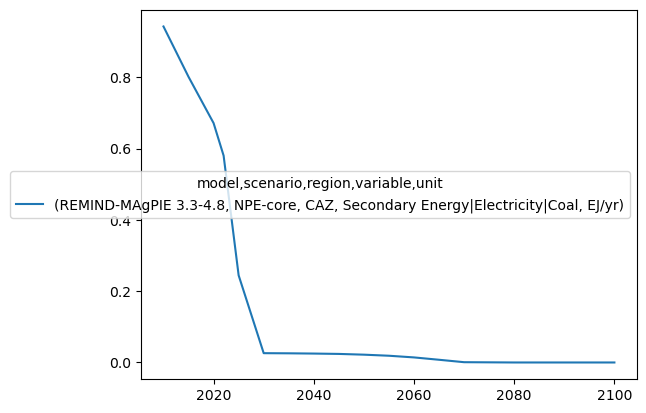

In [ ]:
dscale_results_agg.filter(region="CAZ",variable = "Secondary Energy|Electricity|Coal", scenario = "NPE-core").timeseries().T.plot()
input_data.filter(region="CAZ",variable = "Secondary Energy|Electricity|Coal", scenario = "NPE-core").timeseries().T.plot()

<class 'pyam.core.IamDataFrame'>
Index:
 * model    : REMIND-MAgPIE 3.3-4.8 (1)
 * scenario : NPE-core (1)
Timeseries data coordinates:
   region   : CAZ (1)
   variable : Secondary Energy|Electricity|Coal (1)
   unit     : EJ/yr (1)
   year     : 2005, 2010, 2015, 2020, 2025, 2030, 2035, 2040, ... 2100 (16)
Meta indicators:
   exclude (bool) False (1)

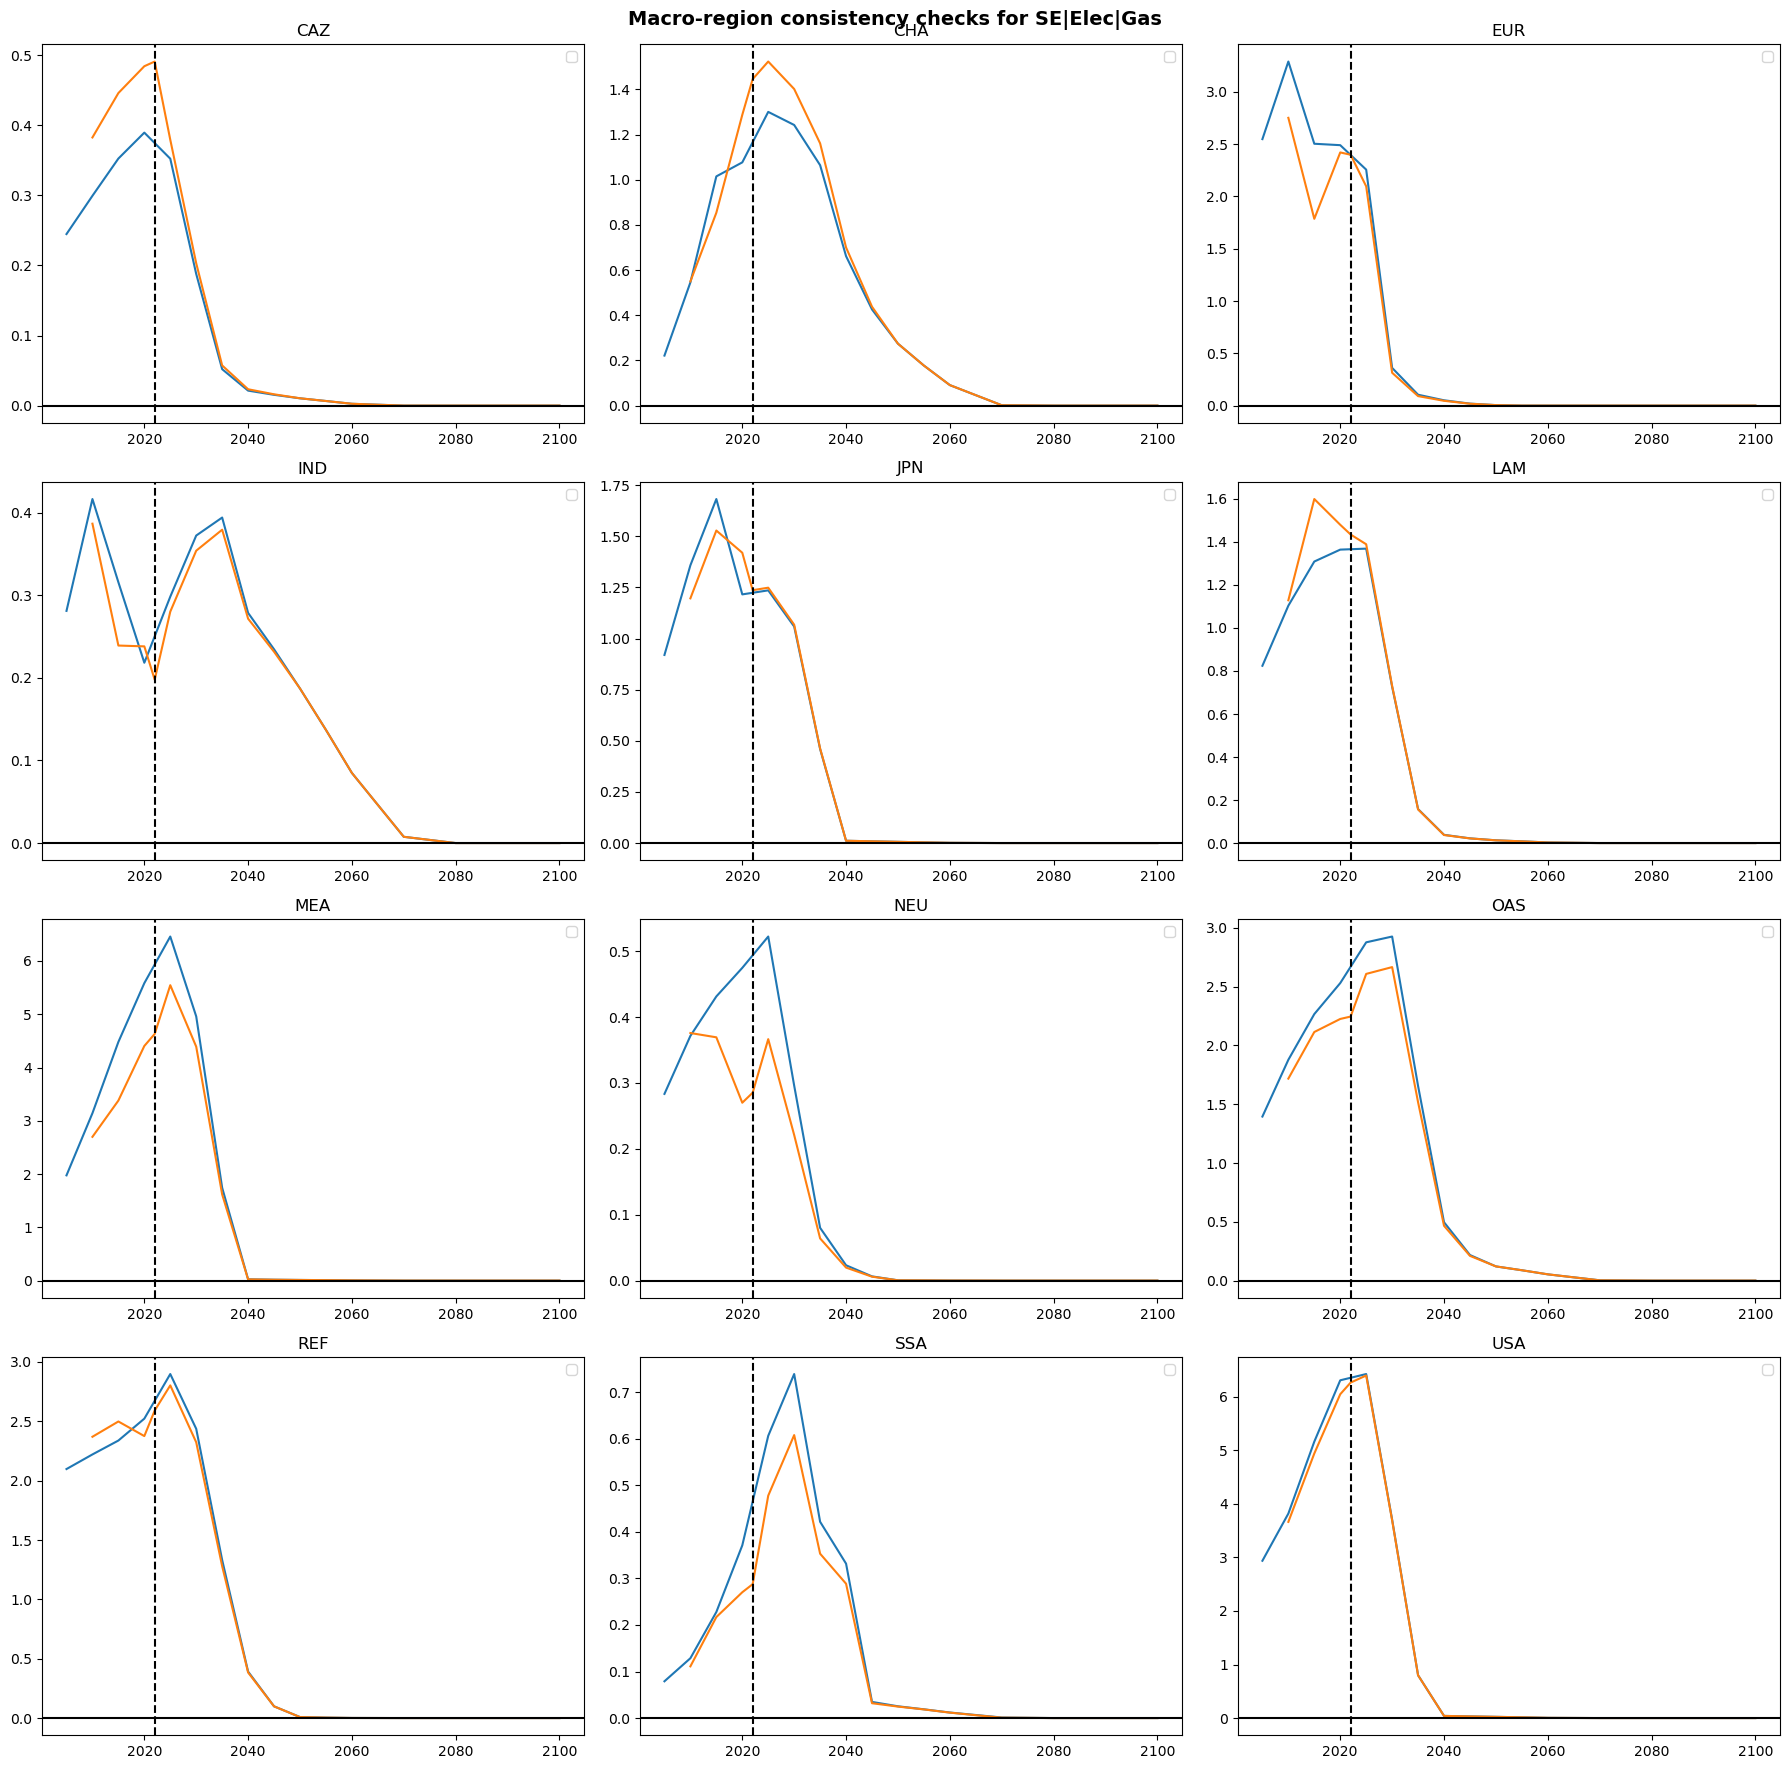

In [70]:
f, axes = plt.subplots(nrows=4,ncols=3,figsize=(18,18))
# wns_vars = [elec('Coal'),elec('Gas')]
macro_region = input_data.region

for count, ax in enumerate(axes.ravel()[:]):
    input_data.filter(region=macro_region[count],variable = "Secondary Energy|Electricity|Gas", scenario = "NPE-core").timeseries().T.plot(ax=ax)
    dscale_results_agg.filter(region=macro_region[count],variable = "Secondary Energy|Electricity|Gas", scenario = "NPE-core").timeseries().T.plot(ax=ax)
    # hist_data.filter(region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(macro_region[count])
    ax.legend([])


f.suptitle('Macro-region consistency checks for SE|Elec|Gas',fontsize=14,fontweight='bold')
# f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

In [26]:
change_in_macro_data.loc[isin(variable = "Secondary Energy|Electricity|Gas")]

2005  \
model                 scenario region variable                         unit                                    
REMIND-MAgPIE 3.3-4.8 NPE-core CAZ    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               CHA    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               EUR    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               IND    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               JPN    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               LAM    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               MEA    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               NEU    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               OAS    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               REF    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               SSA    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               USA    Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   
                               World  Secondary Energy|Electricity|Gas change_in_results_during_dscale   NaN   

                                                                                                            2010  \
model                 scenario region variable                         unit                                        
REMIND-MAgPIE 3.3-4.8 NPE-core CAZ    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.278051   
                               CHA    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.007628   
                               EUR    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.836376   
                               IND    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.928344   
                               JPN    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.880965   
                               LAM    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.022784   
                               MEA    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.858737   
                               NEU    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.011685   
                               OAS    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.914638   
                               REF    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.067073   
                               SSA    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.864019   
                               USA    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.959346   
                               World  Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.933185   

                                                                                                            2015  \
model                 scenario region variable                         unit                                        
REMIND-MAgPIE 3.3-4.8 NPE-core CAZ    Secondary Energy|Electricity|Gas change_in_results_during_dscale  1.265134   
                               CHA    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.841410   
                               EUR    Secondary Energy|Electricity|Gas change_in_results_during_dscale  0.713314   
                               IND    Secondary Energy|Electricity|Gas change_in_results_during_dscale

In [15]:
change_in_macro_data[change_in_macro_data[[2030]].gt(1.1).any(axis=1)][2030]

model                  scenario            region  variable                                 unit                           
REMIND-MAgPIE 3.3-4.8  NPE-core            CAZ     Emissions|CO2|Industrial Processes       change_in_results_during_dscale    1.836728
                                                   Primary Energy|Gas                       change_in_results_during_dscale    1.179536
                                                   Primary Energy|Gas|w/o CCS               change_in_results_during_dscale    1.187402
                                                   Primary Energy|Nuclear                   change_in_results_during_dscale    1.482519
                                                   Primary Energy|Solar                     change_in_results_during_dscale    1.202364
                                                                                                                                 ...   
                       NPE-demandStandard  World   Capital C

In [16]:
change_in_macro_data[change_in_macro_data[[2030]].lt(0.9).any(axis=1)][2030]

model                  scenario            region  variable                                  unit                           
REMIND-MAgPIE 3.3-4.8  NPE-core            CAZ     Carbon Sequestration|CCS                  change_in_results_during_dscale    0.713897
                                                   Emissions|CO2                             change_in_results_during_dscale    0.528073
                                                   Final Energy|Heat                         change_in_results_during_dscale    0.539120
                                                   Final Energy|Transportation|Liquids|Coal  change_in_results_during_dscale    0.000000
                                                   Primary Energy|Oil                        change_in_results_during_dscale    0.892960
                                                                                                                                  ...   
                       NPE-demandStandard  World   Se

### Variables lost through downscaling

In [17]:
missing_vars = set(input_data.variable) - set(dscale_results.variable)
len(missing_vars)

116

In [18]:
missing_co2_vars = list(filter(lambda s:'Emissions|CO2' in s,missing_vars))
missing_co2_vars

['Emissions|CO2|Energy|Demand|Transportation|Rail|Passenger',
 'Emissions|CO2|Energy|Demand|Transportation|Road',
 'Emissions|CO2|Energy|Supply',
 'Emissions|CO2|AFOLU',
 'Emissions|CO2|Energy|Demand|Industry|Cement',
 'Emissions|CO2|Energy|Demand|Transportation|Road|Freight',
 'Emissions|CO2|Energy|Demand|Transportation|Road|Passenger|Bus',
 'Emissions|CO2|Energy|Supply|Extraction',
 'Emissions|CO2|Energy|Supply|Gases',
 'Emissions|CO2|Energy|Demand|Transportation|Road|Passenger|LDV',
 'Emissions|CO2|Energy|Supply|Other Sector',
 'Emissions|CO2|Energy|Demand',
 'Emissions|CO2|Energy|Demand|Transportation|Rail|Freight',
 'Emissions|CO2|Energy|Demand|Transportation|Road|Passenger',
 'Emissions|CO2|Energy|Demand|Industry|Steel',
 'Emissions|CO2|Energy|Demand|Transportation|Aviation|Passenger',
 'Emissions|CO2|Energy|Demand|Industry|Chemicals',
 'Emissions|CO2|Energy and Industrial Processes',
 'Emissions|CO2|Energy|Supply|Liquids',
 'Emissions|CO2|Energy|Supply|Heat',
 'Emissions|CO2|Ene

### Loss of regional detail (where not all variables exist for all regions)

In [19]:
regional_coverage = pd.DataFrame(columns=['regional_coverage','regions'])

for var in dscale_results.variable:
    filter_idf = dscale_results.filter(variable=var)
    regional_coverage.loc[var,'regional_coverage'] = len(filter_idf.region)
    regional_coverage.loc[var,'regions'] = filter_idf.region

In [20]:
regional_coverage.value_counts('regional_coverage').sort_index(ascending=True)

regional_coverage
3      303
28       1
31       2
46       1
87       1
100      2
103      1
117      1
118      1
120      1
128      2
139      2
140      1
142      1
147      2
168      1
173      4
184      1
186      2
193    155
194      1
218      4
dtype: int64

In [21]:
grs = list() # groups of names with distance > 70
for name in regional_coverage.loc[regional_coverage.regional_coverage == 3].index:
    for g in grs:
        if all(fuzz.ratio(name, w) > 70 for w in g):
            g.append(name)
            break
    else:
        grs.append([name, ])

In [22]:
typical_vars = []
for gr in grs:
    typical_vars.append(gr[0])

typical_vars

['Capacity Additions|Electricity|Biomass',
 'Capacity|Electricity',
 'Capacity|Electricity|Nuclear',
 'Capacity|Gases',
 'Capacity|Hydrogen',
 'Capacity|Hydrogen|Biomass|w/ CCS',
 'Capacity|Hydrogen|Electricity',
 'Capacity|Liquids',
 'Capital Cost|Electricity|Biomass|w/ CCS',
 'Capital Cost|Electricity|Wind|Offshore',
 'Capital Cost|Gases|Biomass|w/o CCS',
 'Capital Cost|Liquids|Oil',
 'Carbon Sequestration|CCS|Biomass|Energy|Demand|Industry',
 'Consumption',
 'Emissions|CO2|Energy|Demand|Transportation',
 'Emissions|HFC|HFC43-10',
 'Emissions|NH3|AFOLU',
 'Emissions|NOx|Other',
 'Energy Service|Residential and Commercial|Floor Space',
 'Energy Service|Transportation|Freight',
 'Energy Service|Transportation|Passenger',
 'Final Energy|Hydrogen',
 'Final Energy|Industry|Cement',
 'Final Energy|Industry|Chemicals|Gases',
 'Final Energy|Industry|Gases|Bioenergy',
 'Final Energy|Industry|Other|Electricity',
 'Final Energy|Other Sector',
 'Final Energy|Residential and Commercial|Heating',


In [23]:
regional_coverage.loc[regional_coverage.regional_coverage == 3]

,regional_coverage,regions
Capacity Additions|Electricity|Biomass,3,"[IND, JPN, USA]"
Capacity Additions|Electricity|Biomass|w/ CCS,3,"[IND, JPN, USA]"
Capacity Additions|Electricity|Biomass|w/o CCS,3,"[IND, JPN, USA]"
Capacity Additions|Electricity|Coal,3,"[IND, JPN, USA]"
Capacity Additions|Electricity|Coal|w/ CCS,3,"[IND, JPN, USA]"
...,...,...
Secondary Energy|Liquids|Gas|w/ CCS,3,"[IND, JPN, USA]"
Secondary Energy|Liquids|Gas|w/o CCS,3,"[IND, JPN, USA]"
Statistical Difference|Emissions|CO2,3,"[IND, JPN, USA]"
Transport|Stock|Road|Passenger|Bus,3,"[IND, JPN, USA]"


## Plotting data

In [15]:
IKEA_ISOS = ["DEU","POL","BRA","MEX","KEN","MAR","MOZ",
             "NGA","SEN","ZAF","USA","NAM","DZA","TUR","SAU",
             "ARE","BGD","IND","IDN","PAK","VNM","GBR","AUS","CHN","JPN"]

IKEA_ISOS.sort()

### Primary Energy

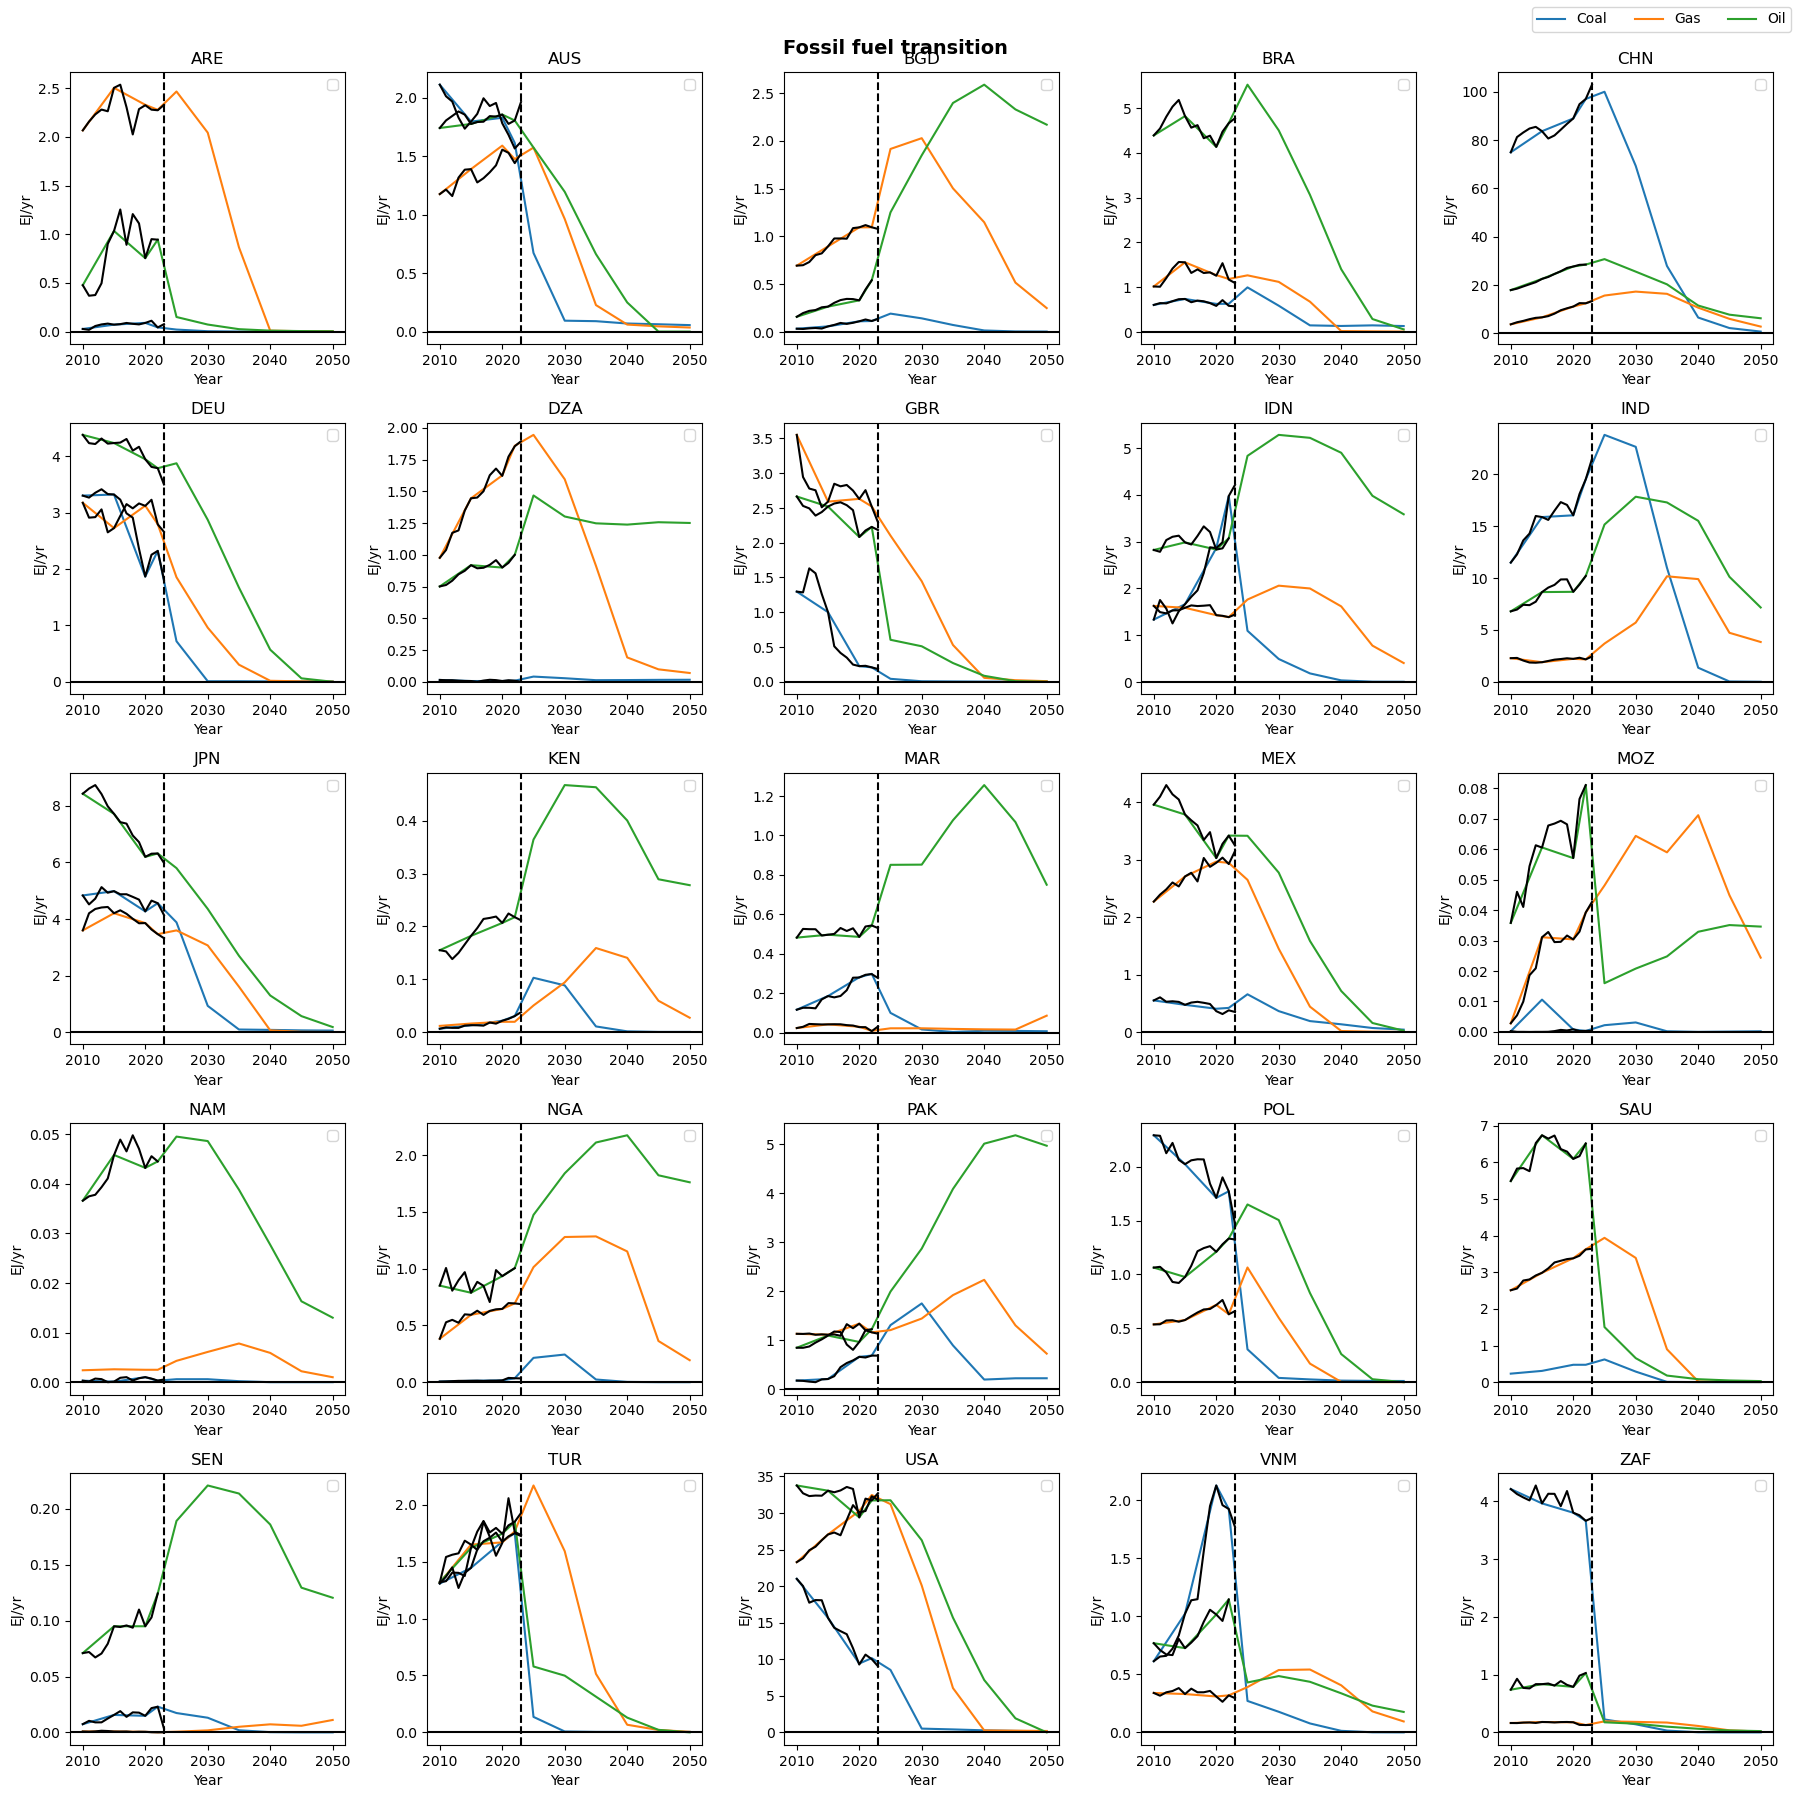

In [26]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
fossil_vars = ['Primary Energy|Coal','Primary Energy|Oil','Primary Energy|Gas']

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=fossil_vars,year=range(2010,2051)).plot(ax=ax)
    hist_data.filter(region=IKEA_ISOS[count],variable=fossil_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])

f.suptitle('Fossil fuel transition',fontsize=14,fontweight='bold')
f.legend(['Coal','Gas','Oil'],ncols=3)
plt.tight_layout()

### Electricity generation

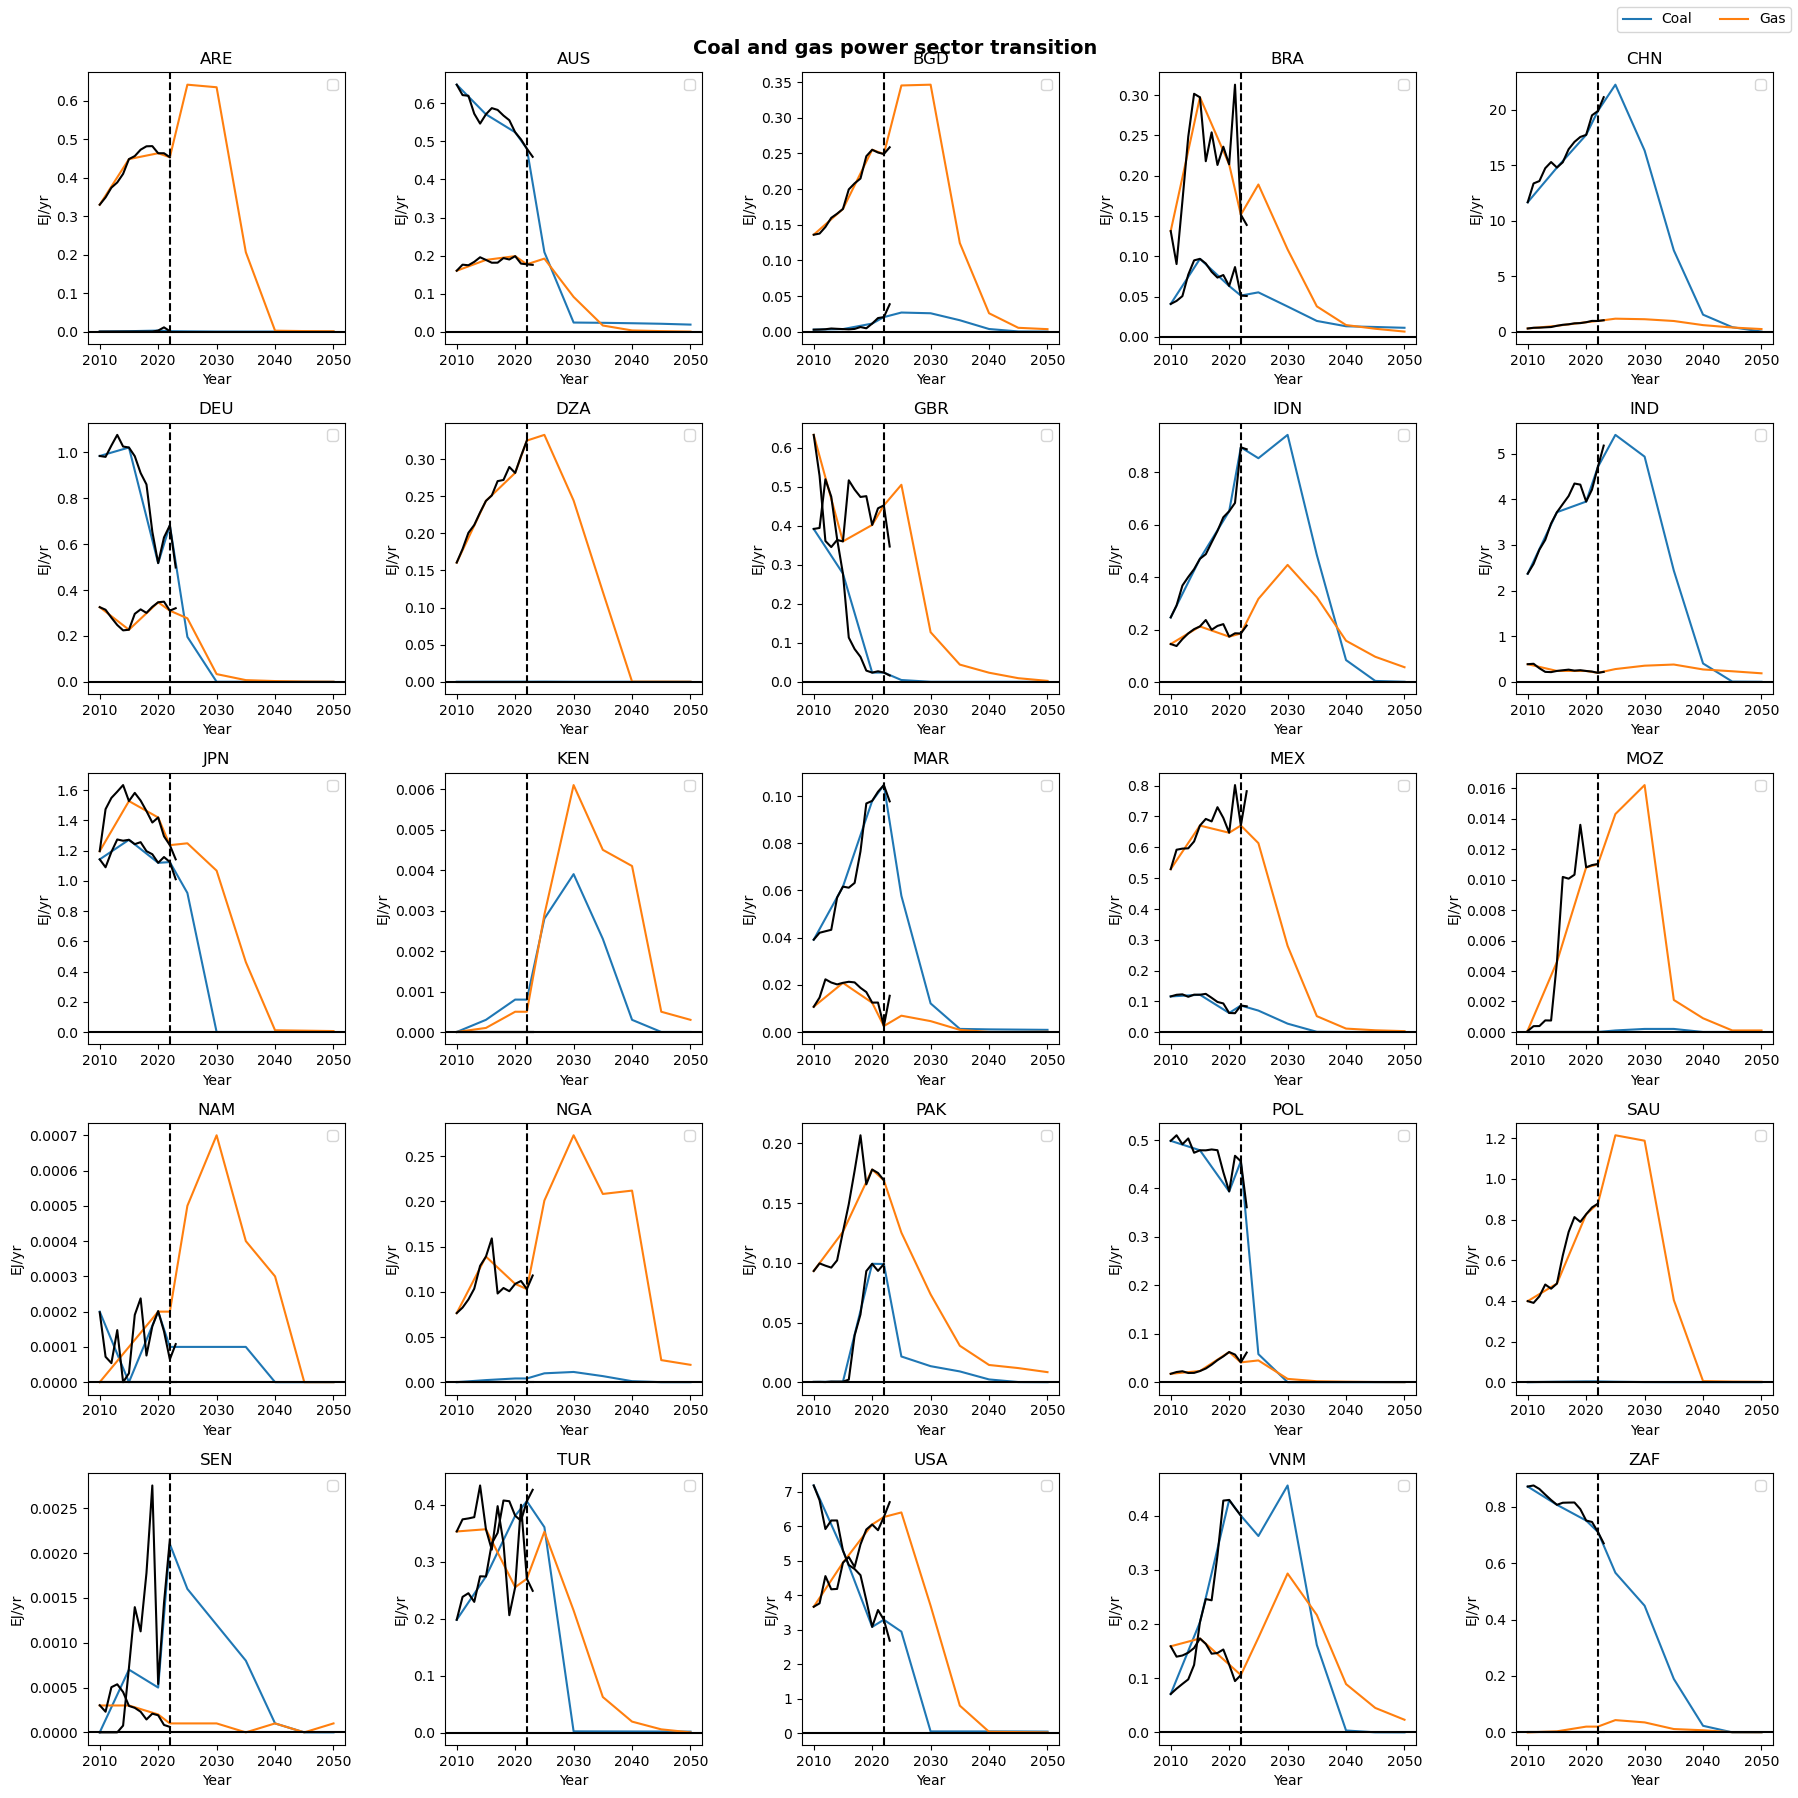

In [22]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
wns_vars = [elec('Coal'),elec('Gas')]

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2051)).plot(ax=ax)
    hist_data.filter(region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2022,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Coal and gas power sector transition',fontsize=14,fontweight='bold')
f.legend(['Coal','Gas'],ncols=2)
plt.tight_layout()

Looking into the weird drop off in ZAF

In [37]:
(
    input_data
    .filter(variable=elec('Coal'),region='SSA',scenario='*core',year=[2020,2025])
    .convert_unit('EJ/yr','TWh / yr')
    .timeseries()#.diff(axis=1)
    .dropna(axis=1,how='all')
)

# Region as a whole doesn't have crazy drop off

,,,,,2020,2025
model,scenario,region,variable,unit,,
REMIND-MAgPIE 3.3-4.8,NPE-core,SSA,Secondary Energy|Electricity|Coal,TWh / yr,187.5265,160.281


In [33]:
historical_coal_generation_afr = (
    hist_data
    .filter(variable=elec('Coal'),region=REMIND_RMAP.get_sub_regions('SSA'),year=range(2010,2025))
    .convert_unit('EJ/yr','TWh / yr')
    .timeseries().sum()
)

historical_coal_generation_afr

# Historical data is broadly matched to regional data in 2020

2010    246.683
2011    248.854
2012    245.288
2013    241.164
2014    237.448
2015    233.608
2016    235.451
2017    236.362
2018    238.374
2019    231.416
2020    217.105
2021    215.688
2022    207.154
2023    189.352
dtype: float64

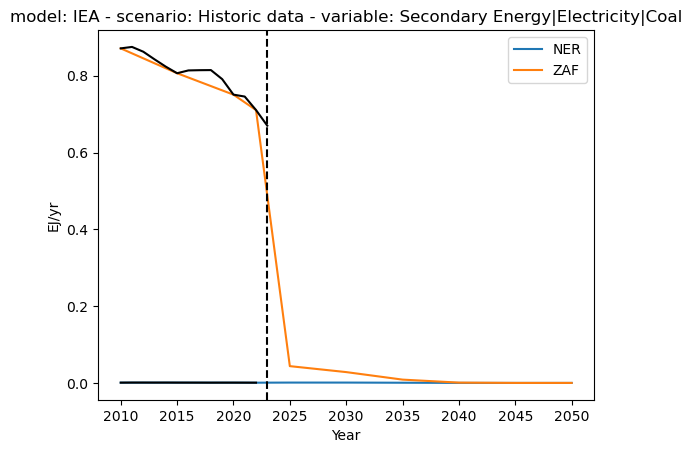

In [36]:
(
    dscale_results
    .filter(variable=elec('Coal'),region=['NER','ZAF'],scenario='*core',year=range(2010,2051))
).plot()

(
    hist_data
    .filter(variable=elec('Coal'),region=['NER','ZAF'],scenario='*',year=range(2010,2051))
).plot(ax=plt.gca(),color='k')

ax = plt.gca()
ax.axvline(x=2023,color='k',ls='--')

# ISSUE is in NER -> sudden boost of elec(Coal)!

In [35]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
wns_vars = ['Secondary Energy|Electricity|Wind','Secondary Energy|Electricity|Solar']

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-convEarly',region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2051)).plot(ax=ax)
    hist_data.filter(region=IKEA_ISOS[count],variable=wns_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Wind and solar transition',fontsize=14,fontweight='bold')
f.legend(['Solar','Wind'],ncols=2)
plt.tight_layout()

pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!
pyam.core - WARNING: Filtered IamDataFrame is empty!


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x17f317b80> (for post_execute):


KeyboardInterrupt: 

In [50]:
missing_nuclear_regions = set(IKEA_ISOS) - set(dscale_results.filter(variable=elec('Nuclear'),region=IKEA_ISOS).region)
missing_nuclear_regions

dscale_results.append(
    pd.DataFrame(0,
    columns=dscale_results.year,
    index=pd.MultiIndex.from_product(
        [dscale_results.model, dscale_results.scenario, list(missing_nuclear_regions), [elec('Nuclear')], ['EJ/yr']],
        names=["model", "scenario", "region", "variable", "unit"],
    )),
    inplace=True
)

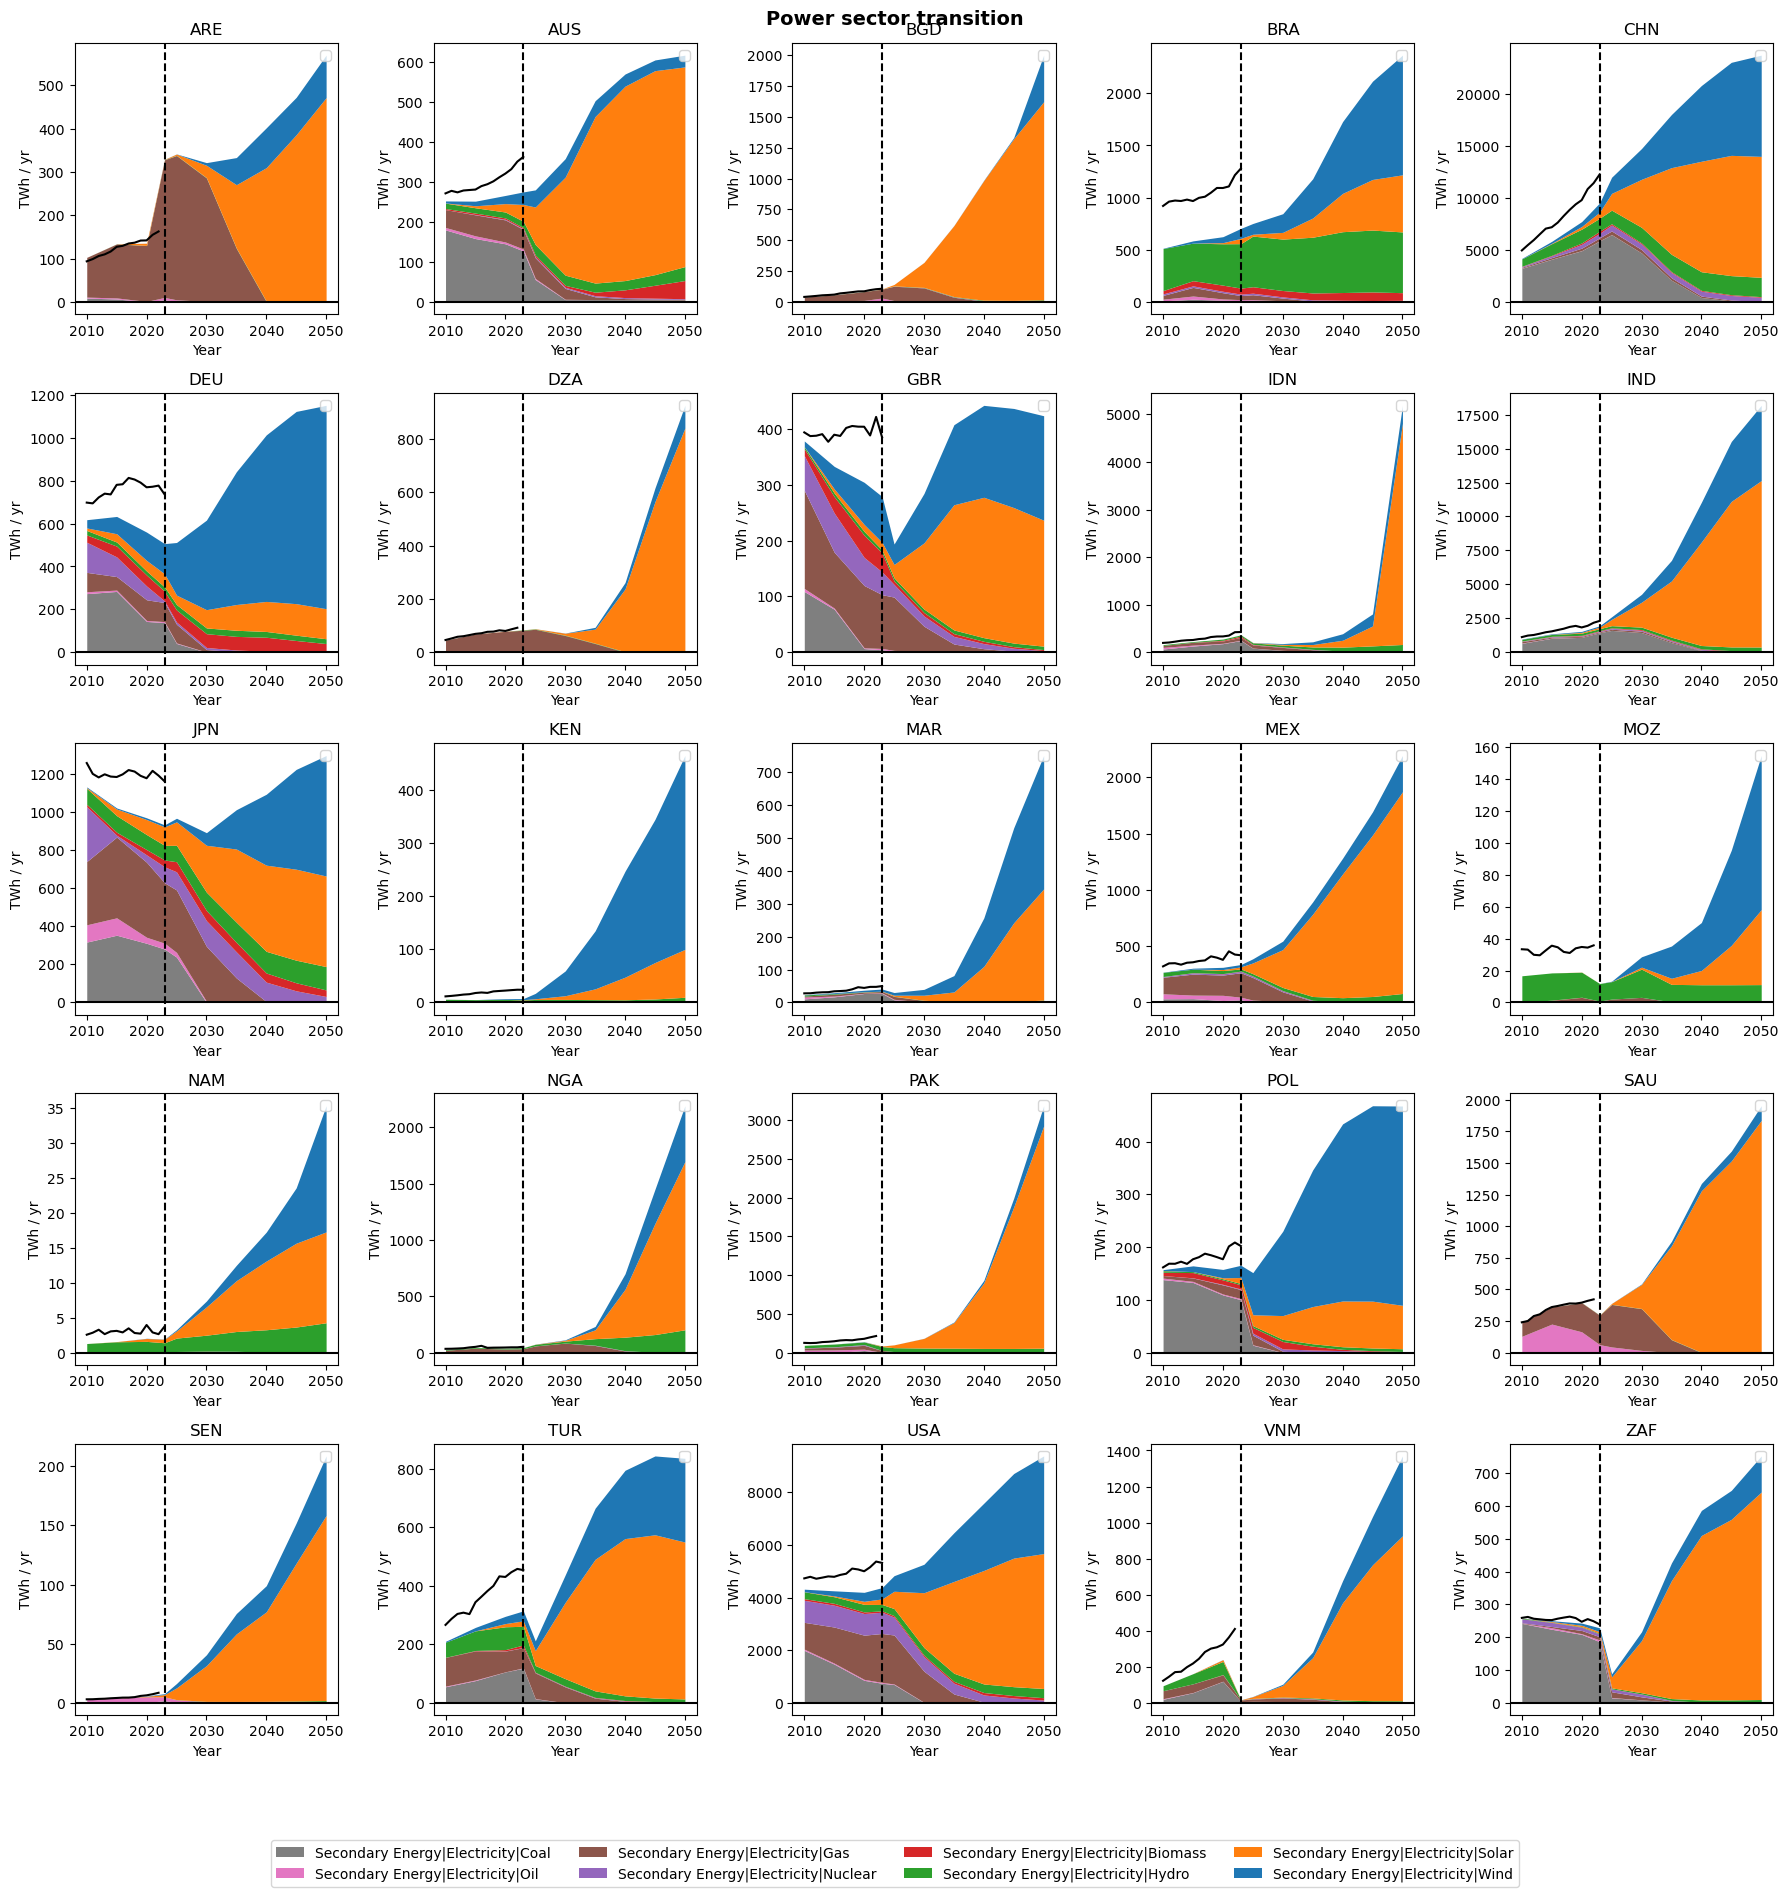

In [51]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
elec_vars = [elec(f) for f in ['Coal','Oil','Gas','Nuclear','Biomass','Hydro','Solar','Wind',]]

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-convEarly',region=IKEA_ISOS[count],variable=elec_vars,year=range(2010,2051)).convert_unit('EJ/yr','TWh / yr').plot.stack(ax=ax,order=elec_vars[::-1])
    hist_data.filter(region=IKEA_ISOS[count],variable=elec(),year=range(2010,2025)).convert_unit('EJ/yr','TWh / yr').plot(ax=ax,color='k',lw=1.5)
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Power sector transition',fontsize=14,fontweight='bold')
f.legend(elec_vars,ncols=4,loc='center',bbox_to_anchor=[0.5,-0.05])
plt.tight_layout()



In [61]:
elec_vars

['Secondary Energy|Electricity|Coal',
 'Secondary Energy|Electricity|Oil',
 'Secondary Energy|Electricity|Gas',
 'Secondary Energy|Electricity|Nuclear',
 'Secondary Energy|Electricity|Biomass',
 'Secondary Energy|Electricity|Hydro',
 'Secondary Energy|Electricity|Solar',
 'Secondary Energy|Electricity|Wind']

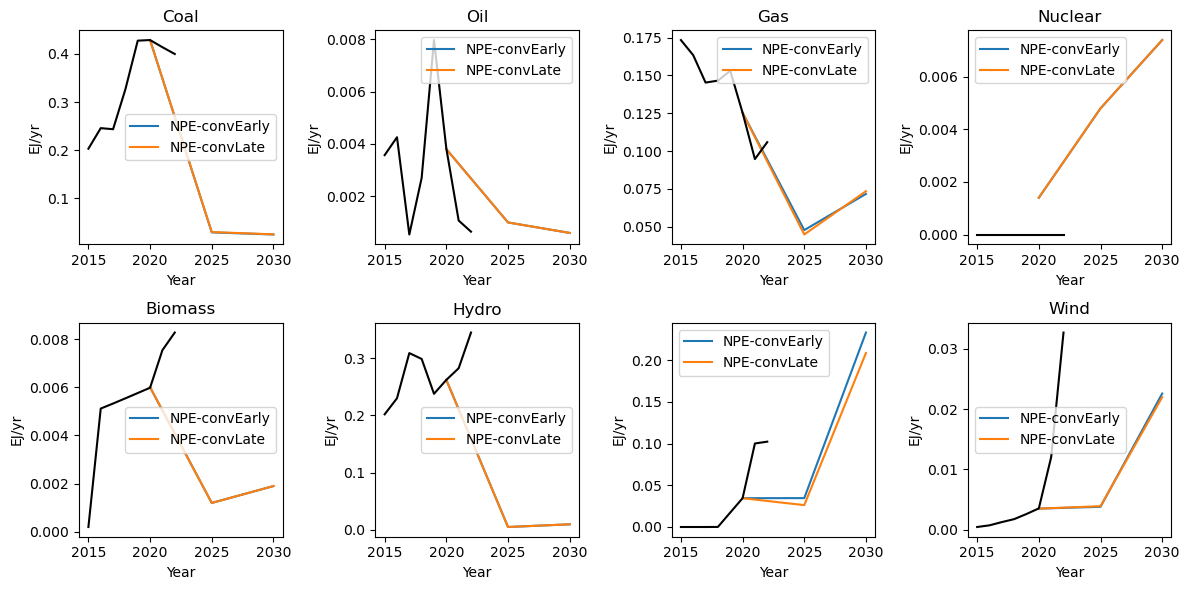

In [60]:
f, axes = plt.subplots(nrows=2,ncols=4,figsize=(12,6))

for count, ax in enumerate(axes.ravel()):
    dscale_results.filter(variable=elec_vars[count],region='VNM',year=[2020,2025,2030]).plot(ax=ax)
    hist_data.filter(variable=elec_vars[count],region='VNM',year=range(2015,2024)).plot(ax=ax,color='k')
    ax.set_title(elec_vars[count].lstrip('Secondary Energy|Electricity'))

plt.tight_layout()

### Final Energy

In [62]:
dscale_results.filter(variable='Final Energy|Transportation|Liqu*',region='USA').timeseries()

2010  \
model                 scenario      region variable                                 unit             
REMIND-MAgPIE 3.3-4.8 NPE-convEarly USA    Final Energy|Transportation|Liquids      EJ/yr  26.5017   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  26.0443   
                      NPE-convLate  USA    Final Energy|Transportation|Liquids      EJ/yr  26.5017   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  26.0443   

                                                                                              2015  \
model                 scenario      region variable                                 unit             
REMIND-MAgPIE 3.3-4.8 NPE-convEarly USA    Final Energy|Transportation|Liquids      EJ/yr  26.8558   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.9587   
                      NPE-convLate  USA    Final Energy|Transportation|Liquids      EJ/yr  26.8558   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.9587   

                                                                                              2020  \
model                 scenario      region variable                                 unit             
REMIND-MAgPIE 3.3-4.8 NPE-convEarly USA    Final Energy|Transportation|Liquids      EJ/yr  26.5551   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.3756   
                      NPE-convLate  USA    Final Energy|Transportation|Liquids      EJ/yr  26.5551   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.3756   

                                                                                              2023  \
model                 scenario      region variable                                 unit             
REMIND-MAgPIE 3.3-4.8 NPE-convEarly USA    Final Energy|Transportation|Liquids      EJ/yr  26.5551   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.3756   
                      NPE-convLate  USA    Final Energy|Transportation|Liquids      EJ/yr  26.5551   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  25.3756   

                                                                                              2025  \
model                 scenario      region variable                                 unit             
REMIND-MAgPIE 3.3-4.8 NPE-convEarly USA    Final Energy|Transportation|Liquids      EJ/yr  25.2487   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  24.0815   
                      NPE-convLate  USA    Final Energy|Transportation|Liquids      EJ/yr  25.2487   
                                           Final Energy|Transportation|Liquids|Coal EJ/yr   0.0000   
                                           Final Energy|Transportation|Liquids|Oil  EJ/yr  24.0815   

         

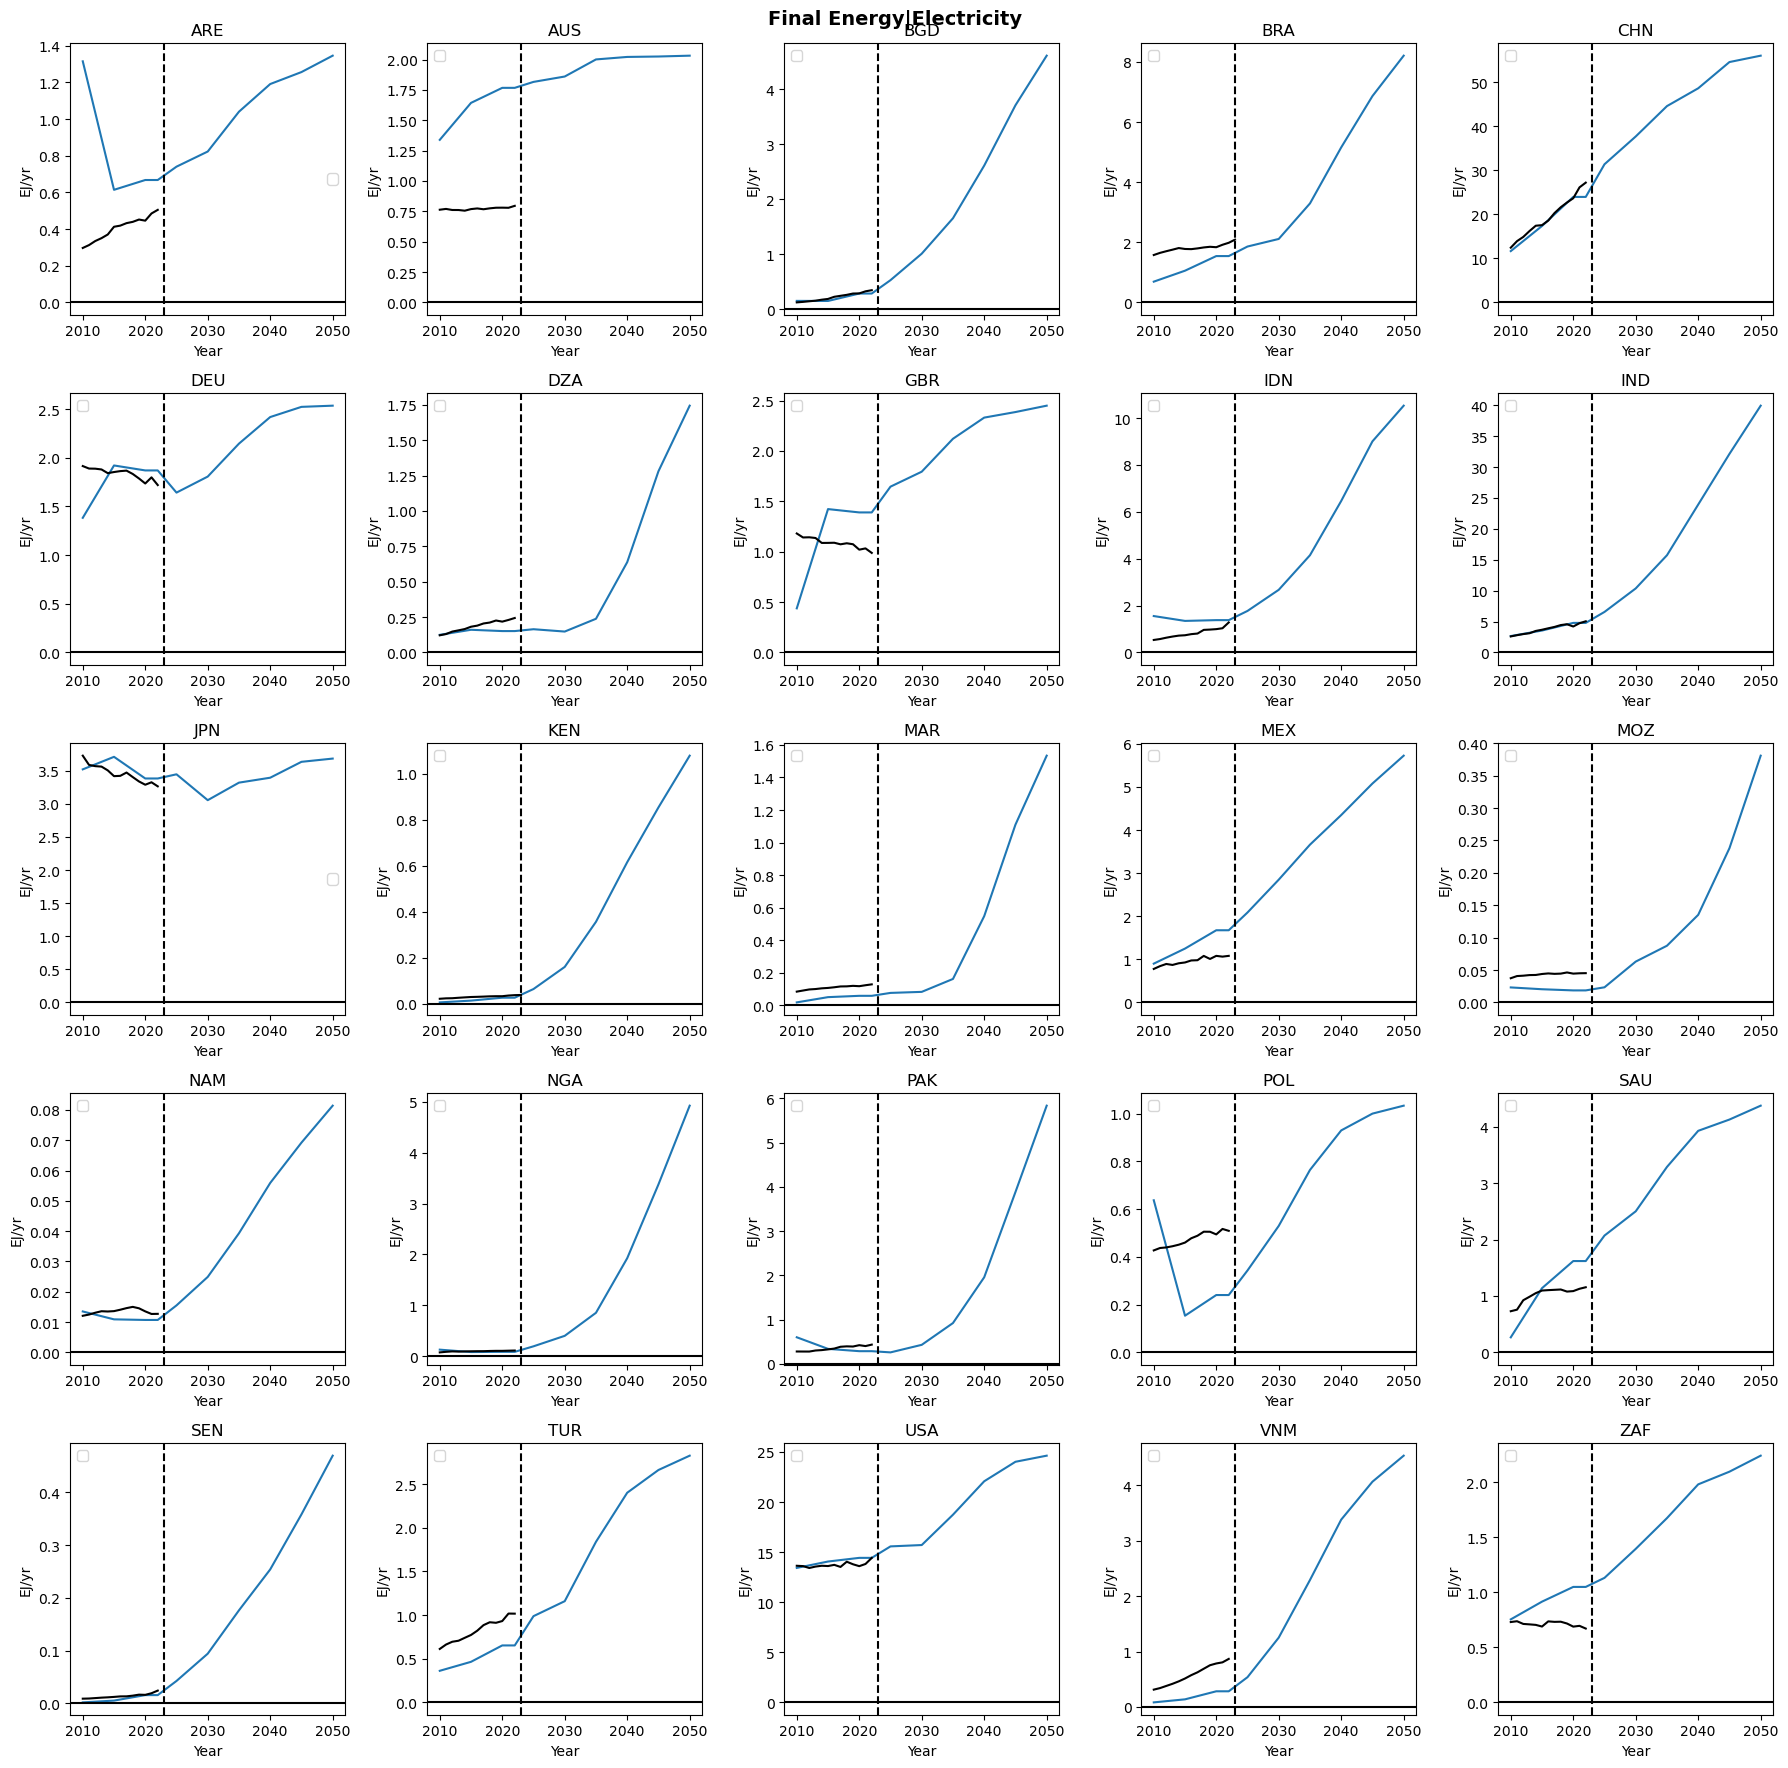

In [18]:
f, axes = plt.subplots(nrows=5,ncols=5,figsize=(18,18))
plot_vars = ['Final Energy|Electricity']

for count, ax in enumerate(axes.ravel()[:]):
    dscale_results.filter(scenario='NPE-core',region=IKEA_ISOS[count],variable=plot_vars,year=range(2010,2051)).plot(ax=ax)
    hist_data.filter(region=IKEA_ISOS[count],variable=plot_vars,year=range(2010,2025)).plot(ax=ax,color='k')
    ax.axvline(x=2023,color='k',ls='--')
    ax.axhline(y=0,color='k',ls='-')
    ax.set_title(IKEA_ISOS[count])
    ax.legend([])


f.suptitle('Final Energy|Electricity',fontsize=14,fontweight='bold')
plt.tight_layout()